In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("../data/human_vital_signs_dataset_2024.csv")

# Select the 8 core features for Milestone 2
features = [
    'Heart Rate', 'Respiratory Rate', 'Body Temperature', 
    'Oxygen Saturation', 'Systolic Blood Pressure', 
    'Diastolic Blood Pressure', 'Derived_HRV', 'Derived_MAP'
]

# Basic statistical inspection
print("Baseline Physiological Ranges:")
display(df[features].describe())

Baseline Physiological Ranges:


,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Derived_HRV,Derived_MAP
count,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000
mean,79.533747,15.489451,36.748353,97.504372,124.437971,79.499625,0.099970,94.479074
std,11.552894,2.294472,0.433290,1.442598,8.656946,5.757248,0.028861,4.797891
min,60.000000,12.000000,36.000004,95.000007,110.000000,70.000000,0.050000,83.333333
25%,70.000000,13.000000,36.372613,96.256859,117.000000,75.000000,0.074955,91.000000
50%,80.000000,15.000000,36.747741,97.509629,124.000000,79.000000,0.099988,94.333333
75%,90.000000,17.000000,37.123003,98.755722,132.000000,84.000000,0.124917,98.000000
max,99.000000,19.000000,37.499992,99.999963,139.000000,89.000000,0.149999,105.666667


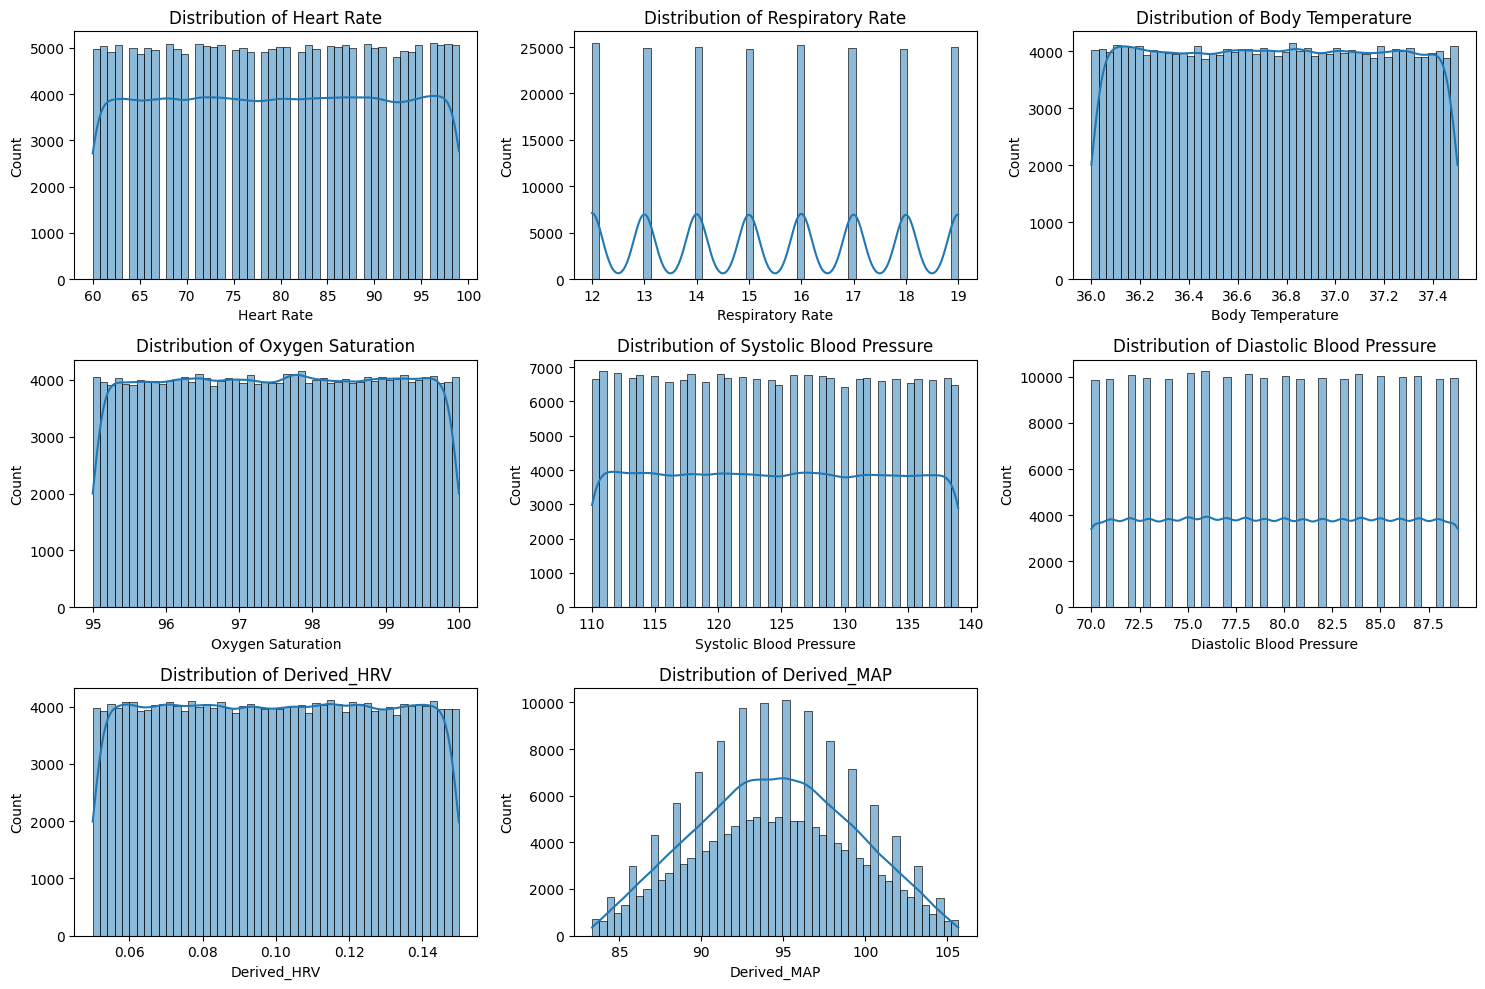

In [3]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[feature], kde=True, bins=50)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

In [4]:
# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the selected features
scaled_data = scaler.fit_transform(df[features])

# Convert back to DataFrame for verification
df_scaled = pd.DataFrame(scaled_data, columns=features)

print("Scaled Data Preview (Mean ≈ 0, Std ≈ 1):")
display(df_scaled.head())
display(df_scaled.info())

Scaled Data Preview (Mean ≈ 0, Std ≈ 1):


,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Derived_HRV,Derived_MAP
0,-1.690814,-1.520811,0.261613,-1.249365,-0.050592,1.129080,0.729803,0.872801
1,-1.431138,1.094175,-0.546333,-0.564926,0.180437,0.781691,0.592199,0.733851
2,-1.431138,-0.213318,0.700908,0.695894,0.758009,-0.260477,-1.620564,0.247525
3,1.684972,0.222513,-0.216034,-1.727839,-0.743679,-1.302644,-1.229902,-1.489354
4,-0.911787,0.222513,0.523310,0.775977,1.566611,-0.607866,0.641494,0.455950


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200020 entries, 0 to 200019
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Heart Rate                200020 non-null  float64
 1   Respiratory Rate          200020 non-null  float64
 2   Body Temperature          200020 non-null  float64
 3   Oxygen Saturation         200020 non-null  float64
 4   Systolic Blood Pressure   200020 non-null  float64
 5   Diastolic Blood Pressure  200020 non-null  float64
 6   Derived_HRV               200020 non-null  float64
 7   Derived_MAP               200020 non-null  float64
dtypes: float64(8)
memory usage: 12.2 MB


None

In [5]:
import joblib
import os

# Ensure the models directory exists
os.makedirs('../models', exist_ok=True)

# Save the scaler for use in the streaming consumer later
joblib.dump(scaler, '../models/scaler.pkl')
print("✅ Scaler saved to models/scaler.pkl")

✅ Scaler saved to models/scaler.pkl


In [10]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# --- Step A: Define Features ---
features = [
    'Heart Rate', 'Respiratory Rate', 'Body Temperature', 
    'Oxygen Saturation', 'Systolic Blood Pressure', 
    'Diastolic Blood Pressure', 'Derived_HRV', 'Derived_MAP'
]

# --- Step B: Scale the Data ---
scaler = MinMaxScaler()
# Make sure 'df' is the name of your dataframe from Milestone 2
scaled_vitals = scaler.fit_transform(df[features]) 

# --- Step C: Create Sequences ---
def create_sequences(data, window_size=10):
    sequences = []
    # Use +1 to include the very last possible window
    for i in range(len(data) - window_size + 1):
        sequences.append(data[i:i+window_size])
    return np.array(sequences)

window_size = 10
X_sequences = create_sequences(scaled_vitals, window_size)

print(f"✅ Success! Sequence Shape: {X_sequences.shape}") 
# Expected Output: (Samples, 10, 8)

✅ Success! Sequence Shape: (200011, 10, 8)


In [11]:
from sklearn.ensemble import IsolationForest
import joblib

# Initialize Isolation Forest
# contamination=0.05 assumes 5% of your historical data might be anomalous
iso_forest = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)

# Train on the flattened scaled data
iso_forest.fit(scaled_vitals)

# Save to your models folder
joblib.dump(iso_forest, '../models/isolation_forest.pkl')
print("✅ Isolation Forest trained and saved!")

✅ Isolation Forest trained and saved!


In [12]:
def compute_risk_score(auto_error, iso_score):
    # Normalize scores to a 0-1 range
    # iso_score is usually negative for anomalies; we flip it
    combined_score = (auto_error * 0.7) + (abs(iso_score) * 0.3)
    
    if combined_score > 0.8:
        return "HIGH"
    elif combined_score > 0.5:
        return "MEDIUM"
    else:
        return "LOW"

# Example test
sample_error = 0.85
sample_iso = -0.15
print(f"Risk Level: {compute_risk_score(sample_error, sample_iso)}")

Risk Level: MEDIUM
